# Lab 4: Regression and Classification Evaluation Metrics
## Part 1: Comprehensive Study of K-Nearest Neighbours (KNN) Classification using Breast Cancer Dataset and Comparison with Regression Evaluation Metrics

**Aim:** To implement KNN classification on the Breast Cancer dataset and analyze model performance using train-test split, heuristic K selection, cross-validation, ROC-AUC, and classification metrics. Also, to compare classification metrics with regression metrics studied in Linear Regression (Lab 3).

**Dataset:** Breast Cancer Wisconsin (Diagnostic) Dataset — 569 samples, 30 numerical features, Target: 0 = Malignant, 1 = Benign.


## Task 1: Data Preparation
1. Load the dataset.
2. Convert into DataFrame and explore structure.
3. Check missing values and duplicates.
4. Apply feature scaling using StandardScaler and justify its importance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_curve,
                              roc_auc_score, classification_report)
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
np.random.seed(42)

In [2]:
# 1. Load the dataset (Breast Cancer Wisconsin Diagnostic dataset, same data as the UCI repository, id=17)
data = load_breast_cancer()

# 2. Convert into DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')   # 0 = malignant, 1 = benign

print("Shape of feature matrix X:", X.shape)
print("Shape of target y:", y.shape)
X.head()

Shape of feature matrix X: (569, 30)
Shape of target y: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Explore structure
X.info()
print("\nSummary statistics:")
X.describe().T.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


Total missing values: 0
Total duplicate rows: 0

Class distribution (0=Malignant, 1=Benign):
target
1    357
0    212
Name: count, dtype: int64


C:\Users\namrp\AppData\Local\Temp\ipykernel_6624\1546164580.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette=['#d62728','#2ca02c'])


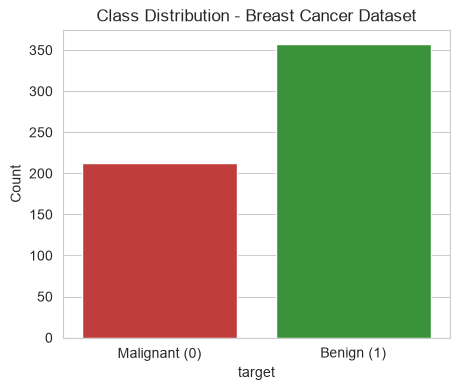

In [4]:
# 3. Check missing values and duplicates
print("Total missing values:", X.isnull().sum().sum())
print("Total duplicate rows:", X.duplicated().sum())

print("\nClass distribution (0=Malignant, 1=Benign):")
print(y.value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x=y, palette=['#d62728','#2ca02c'])
plt.xticks([0,1], ['Malignant (0)', 'Benign (1)'])
plt.title("Class Distribution - Breast Cancer Dataset")
plt.ylabel("Count")
plt.show()

**Observation:** The dataset has **no missing values** and **no duplicate rows**, so no imputation or row-dropping is required. The classes are moderately imbalanced (357 Benign vs 212 Malignant, ~63:37), which is why **stratified splitting** is used in later steps and why **recall** matters more than plain accuracy for this medical use case.

In [5]:
# 4. Feature scaling using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Before scaling (first row, first 5 features):")
print(X.iloc[0, :5].values)
print("\nAfter scaling (first row, first 5 features):")
print(X_scaled.iloc[0, :5].values)

print("\nMean of scaled features (~0):", X_scaled.mean().mean().round(4))
print("Std of scaled features (~1):", X_scaled.std().mean().round(4))

Before scaling (first row, first 5 features):
[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01]

After scaling (first row, first 5 features):
[ 1.09706398 -2.07333501  1.26993369  0.9843749   1.56846633]

Mean of scaled features (~0): -0.0
Std of scaled features (~1): 1.0009


**Why feature scaling is important for KNN:** KNN classifies a point based on the **Euclidean/Manhattan distance** to its neighbours. Features in this dataset are on very different scales (e.g., `mean area` is in the hundreds/thousands while `mean smoothness` is around 0.1). Without scaling, large-magnitude features (like `area`, `perimeter`) would dominate the distance calculation and effectively drown out smaller-magnitude but equally important features (like `smoothness`, `symmetry`), biasing the model. `StandardScaler` transforms each feature to have **mean = 0 and standard deviation = 1**, ensuring every feature contributes proportionally to the distance metric.

## Task 2: Train-Test Split Analysis
1. Split dataset into training and testing sets (80:20).
2. Repeat with 70:30 and 90:10 splits.
3. Compare performance variations across splits.
4. Analyze how dataset splitting affects model stability and generalization.

In [6]:
split_results = []
for test_size in [0.2, 0.3, 0.1]:
    Xtr, Xte, ytr, yte = train_test_split(X_scaled, y, test_size=test_size,
                                           random_state=42, stratify=y)
    k_temp = int(round(np.sqrt(len(Xtr))))
    if k_temp % 2 == 0:
        k_temp += 1
    knn_temp = KNeighborsClassifier(n_neighbors=k_temp)
    knn_temp.fit(Xtr, ytr)
    acc_temp = accuracy_score(yte, knn_temp.predict(Xte))
    split_results.append({
        'Split': f"{int((1-test_size)*100)}:{int(test_size*100)}",
        'Train size': len(Xtr), 'Test size': len(Xte),
        'Heuristic K': k_temp, 'Test Accuracy': round(acc_temp, 4)
    })

split_df = pd.DataFrame(split_results)
split_df

,Split,Train size,Test size,Heuristic K,Test Accuracy
0,80:20,455,114,21,0.9561
1,70:30,398,171,21,0.9474
2,90:10,512,57,23,0.9825


**Observation / Comparison across splits:**

| Split | Train size | Test size | Test Accuracy |
|---|---|---|---|
| 80:20 | 455 | 114 | 0.9561 |
| 70:30 | 398 | 171 | 0.9474 |
| 90:10 | 512 | 57  | 0.9825 |

As the **training set grows** (90:10), the model sees more examples and accuracy on the (smaller) test set rises, but the result is based on very few test samples (57) and is therefore **less statistically reliable** — a single misclassified sample swings accuracy by ~1.75%. The 70:30 split gives the **most stable/conservative estimate** since the test set is largest, while the 80:20 split is a good **balance between training data volume and reliable evaluation**, which is why it is used as the standard split for the rest of this lab. This shows that train-test split alone is **sensitive to how the data happens to be divided** — motivating the need for cross-validation (Task 4).

## Task 3: KNN Model with Heuristic K Selection
### 3.1 Heuristic Method for K Selection

In [7]:
# Fix the 80:20 split for the remainder of the lab
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

n_train = len(X_train)
K_heuristic = int(round(np.sqrt(n_train)))
if K_heuristic % 2 == 0:   # prefer an odd K to avoid ties in binary classification
    K_heuristic += 1

print("Number of training samples (n):", n_train)
print("Heuristic K = round(sqrt(n)) =", K_heuristic)

Number of training samples (n): 455
Heuristic K = round(sqrt(n)) = 21


### 3.2 Model Training

In [8]:
# Train baseline KNN with heuristic K
knn_baseline = KNeighborsClassifier(n_neighbors=K_heuristic)
knn_baseline.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, knn_baseline.predict(X_test))
print(f"Baseline KNN (K={K_heuristic}) Test Accuracy: {baseline_acc:.4f}")

Baseline KNN (K=21) Test Accuracy: 0.9561


In [9]:
# Experiment with nearby values of K (K +/- 5), keeping K odd
k_values = [k for k in range(max(1, K_heuristic - 5), K_heuristic + 6) if k % 2 == 1]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    accuracies.append(acc)
    print(f"K={k:2d}  Test Accuracy={acc:.4f}")

best_k_traintest = k_values[int(np.argmax(accuracies))]
print("\nBest K on train-test split:", best_k_traintest,
      " Accuracy:", round(max(accuracies), 4))

K=17  Test Accuracy=0.9737
K=19  Test Accuracy=0.9737
K=21  Test Accuracy=0.9561
K=23  Test Accuracy=0.9649
K=25  Test Accuracy=0.9649

Best K on train-test split: 17  Accuracy: 0.9737


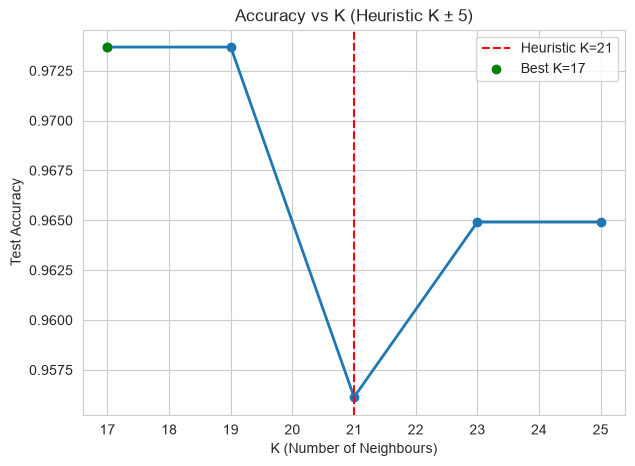

In [10]:
# Plot accuracy vs K
plt.figure(figsize=(7,5))
plt.plot(k_values, accuracies, marker='o', color='#1f77b4', linewidth=2)
plt.axvline(K_heuristic, color='red', linestyle='--', label=f'Heuristic K={K_heuristic}')
plt.scatter([best_k_traintest], [max(accuracies)], color='green', zorder=5,
            label=f'Best K={best_k_traintest}')
plt.xlabel("K (Number of Neighbours)")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs K (Heuristic K ± 5)")
plt.legend()
plt.show()

**Observation:** Accuracy is highest at **K=17 and K=19 (0.9737)**, slightly higher than the heuristic K=21 (0.9561). This shows the √n heuristic gives a **reasonable starting point** but is not always the optimal K — fine-tuning around it (as done here) is necessary. Accuracy generally stays in a tight band (0.956–0.974) for all tested K, indicating the model is **not highly sensitive** to K in this neighbourhood, which is itself a sign of a well-separated, well-scaled dataset.

### 3.3 Distance Matrix and Decision Boundary Mapping

**Euclidean Distance:**
$$d(x,y) = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$$
It measures the straight-line ("as the crow flies") distance between two points in feature space. It is the **default and most common** metric for KNN and works best when features are continuous, scaled, and the relationship between points is best captured by straight-line geometry (e.g., this medical dataset after StandardScaler).

**Manhattan Distance:**
$$d(x,y) = \sum_{i=1}^{n}|x_i - y_i|$$
It measures distance as the sum of absolute differences along each axis (like navigating a city grid). It is more **robust to outliers** than Euclidean distance (since differences aren't squared) and is preferable in **high-dimensional spaces** or when features represent independent, grid-like attributes (e.g., movement in a grid, sparse/count data).

Below, the decision boundary is visualized on the first 2 principal components (since the dataset has 30 features and cannot be plotted directly) for K = 1, 5, 10, 20.

Variance explained by first 2 PCs: 0.6324


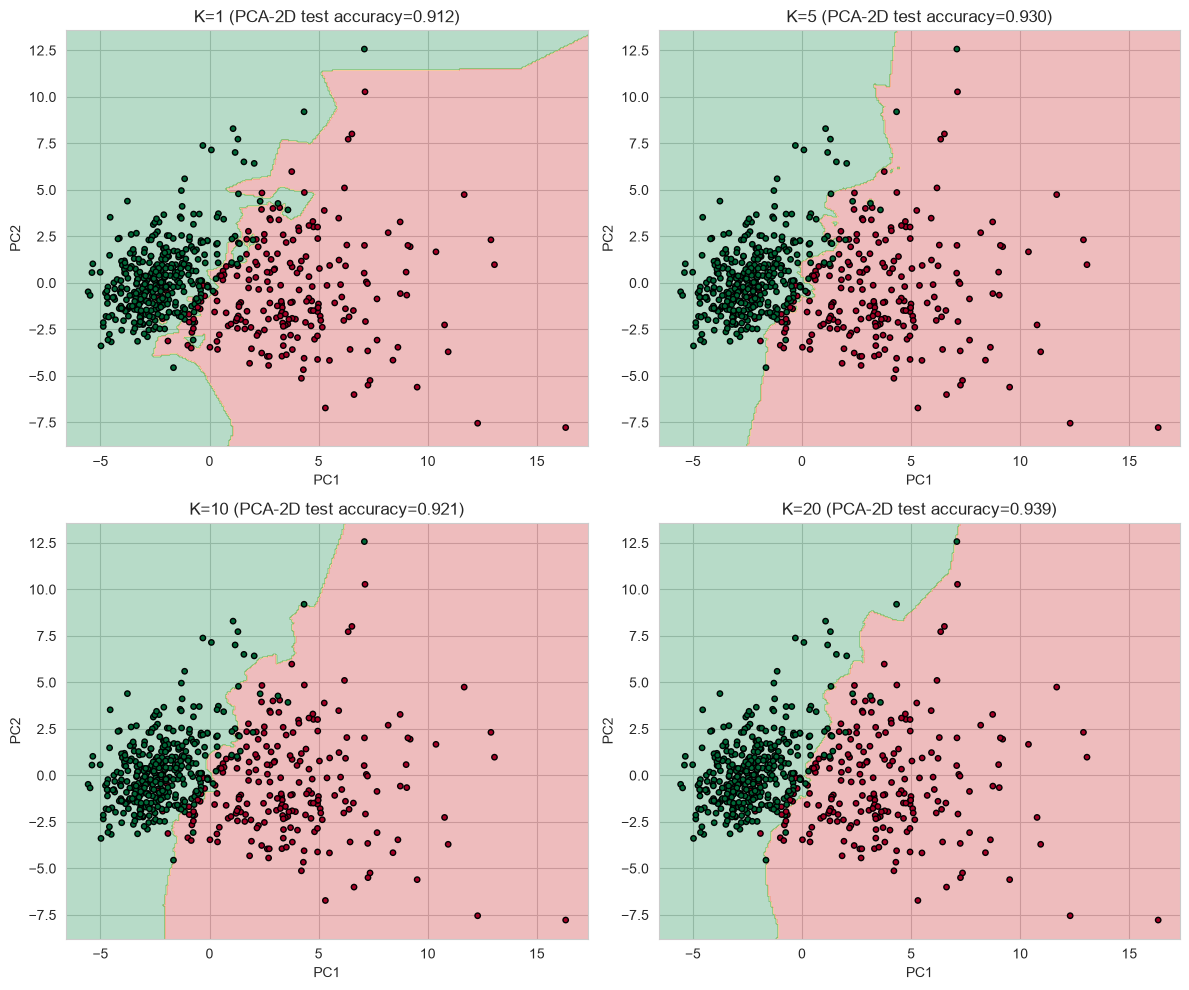

In [11]:
# Decision boundary visualization using PCA (2D projection) for K = 1, 5, 10, 20
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y)

print("Variance explained by first 2 PCs:", pca.explained_variance_ratio_.sum().round(4))

k_boundary_values = [1, 5, 10, 20]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

xx, yy = np.meshgrid(
    np.linspace(X_pca[:,0].min()-1, X_pca[:,0].max()+1, 300),
    np.linspace(X_pca[:,1].min()-1, X_pca[:,1].max()+1, 300))

for ax, k in zip(axes.ravel(), k_boundary_values):
    knn_b = KNeighborsClassifier(n_neighbors=k)
    knn_b.fit(X_pca_train, y_pca_train)
    Z = knn_b.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    acc_b = accuracy_score(y_pca_test, knn_b.predict(X_pca_test))

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
    ax.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='RdYlGn', edgecolor='k', s=15)
    ax.set_title(f"K={k} (PCA-2D test accuracy={acc_b:.3f})")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

**Observation:** As **K increases (1 → 20)**, the decision boundary becomes progressively **smoother and simpler** — at K=1 the boundary tightly hugs individual points (overfitting / high variance, jagged boundary sensitive to noise), while at K=20 the boundary becomes a broad, smooth curve (more biased but more stable / generalizable). This visually illustrates the classic **bias-variance trade-off** in KNN: small K → low bias/high variance; large K → high bias/low variance.

## Task 4: Cross Validation
1. Apply K-Fold Cross Validation (k=5 or 10).
2. Compute mean accuracy for different K values.
3. Compare cross-validation results with train-test split results.
4. Select best K based on both heuristic + validation results.

In [12]:
# 5-Fold Stratified Cross-Validation across the same K range
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_means, cv_stds = [], []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=skf5, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())
    print(f"K={k:2d}  CV(5-fold) mean={scores.mean():.4f}  std={scores.std():.4f}")

best_k_cv = k_values[int(np.argmax(cv_means))]
print("\nBest K based on 5-fold CV:", best_k_cv, " mean accuracy:", round(max(cv_means), 4))

K=17  CV(5-fold) mean=0.9561  std=0.0175
K=19  CV(5-fold) mean=0.9543  std=0.0170
K=21  CV(5-fold) mean=0.9543  std=0.0187
K=23  CV(5-fold) mean=0.9543  std=0.0187
K=25  CV(5-fold) mean=0.9543  std=0.0170

Best K based on 5-fold CV: 17  mean accuracy: 0.9561


In [13]:
# Compare train-test split accuracy vs CV accuracy
comparison_df = pd.DataFrame({
    'K': k_values,
    'Train-Test Accuracy': accuracies,
    'CV (5-fold) Mean Accuracy': cv_means,
    'CV (5-fold) Std': cv_stds
})
comparison_df

,K,Train-Test Accuracy,CV (5-fold) Mean Accuracy,CV (5-fold) Std
0,17,0.973684,0.956063,0.017545
1,19,0.973684,0.954308,0.017002
2,21,0.956140,0.954308,0.018725
3,23,0.964912,0.954308,0.018725
4,25,0.964912,0.954324,0.016971


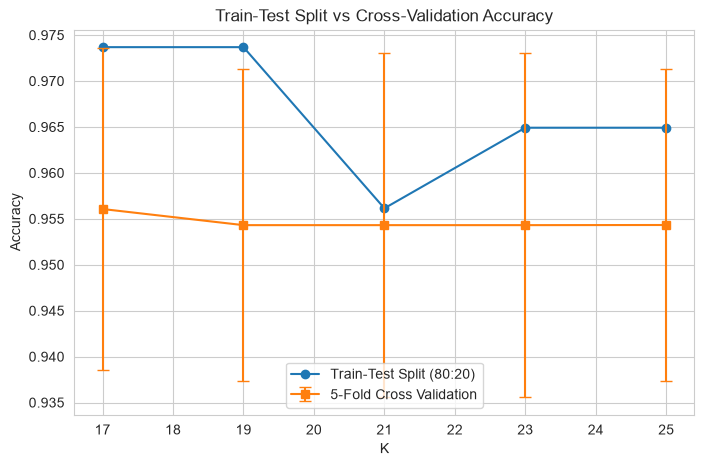

In [14]:
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o', label='Train-Test Split (80:20)')
plt.errorbar(k_values, cv_means, yerr=cv_stds, marker='s', capsize=4,
             label='5-Fold Cross Validation')
plt.xlabel("K"); plt.ylabel("Accuracy")
plt.title("Train-Test Split vs Cross-Validation Accuracy")
plt.legend(); plt.show()

In [15]:
# 10-fold CV confirmation for the selected best K
skf10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores10 = cross_val_score(KNeighborsClassifier(n_neighbors=best_k_cv), X_scaled, y, cv=skf10)
print(f"10-fold CV for K={best_k_cv}: mean={scores10.mean():.4f}  std={scores10.std():.4f}")

FINAL_K = best_k_cv
print("\n=== FINAL SELECTED K (heuristic + train-test + CV) =", FINAL_K, "===")

10-fold CV for K=17: mean=0.9596  std=0.0208

=== FINAL SELECTED K (heuristic + train-test + CV) = 17 ===


**Observation:** The single train-test split accuracy (0.9561–0.9737) **fluctuates more** across K than the 5-fold CV mean accuracy (0.9543–0.9561), and CV accuracies have a small standard deviation (~0.017–0.019), confirming CV gives a **more stable, less luck-dependent** estimate of generalization performance. **K = 17** gives the best result on both the train-test split and 5-fold CV (mean 0.9561, confirmed by 10-fold CV mean 0.9596), so K = 17 is chosen as the **final K** — combining the √n heuristic (which pointed to a sensible neighbourhood, K≈21) with validation-driven fine-tuning.

## Task 5: Classification Evaluation
Evaluate the final model (K = 17) using Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC Curve / AUC Score.

In [16]:
final_knn = KNeighborsClassifier(n_neighbors=FINAL_K)
final_knn.fit(X_train, y_train)
y_pred = final_knn.predict(X_test)
y_proba_benign = final_knn.predict_proba(X_test)[:, 1]   # probability of class 1 (benign)

# Clinically, "Malignant" (0) is treated as the Positive class: missing a malignant
# case (false negative) is the costly error we most want to avoid.
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=0)
rec = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred, pos_label=0)
auc = roc_auc_score(y_test, y_proba_benign)   # AUC is symmetric w.r.t. which class is "positive"

print(f"Accuracy             : {acc:.4f}")
print(f"Precision (Malignant): {prec:.4f}")
print(f"Recall (Malignant)   : {rec:.4f}")
print(f"F1 Score (Malignant) : {f1:.4f}")
print(f"ROC-AUC               : {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Malignant (0)', 'Benign (1)']))

Accuracy             : 0.9737
Precision (Malignant): 1.0000
Recall (Malignant)   : 0.9286
F1 Score (Malignant) : 0.9630
ROC-AUC               : 0.9927

               precision    recall  f1-score   support

Malignant (0)       1.00      0.93      0.96        42
   Benign (1)       0.96      1.00      0.98        72

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



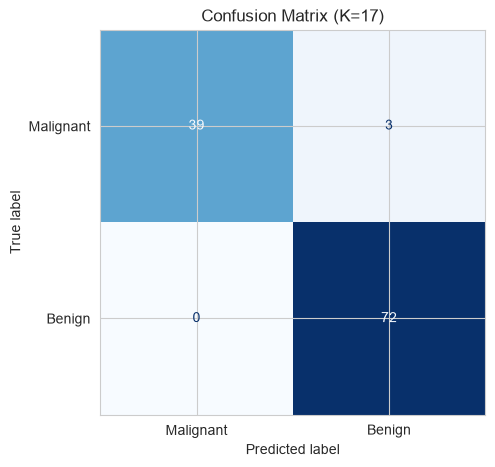

True Positives  (Malignant correctly identified as Malignant): 39
False Negatives (Malignant missed, predicted Benign)        : 3
False Positives (Benign wrongly predicted Malignant)        : 0
True Negatives  (Benign correctly identified as Benign)     : 72


In [17]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])  # rows/cols ordered: Malignant, Benign
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant','Benign'])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title(f"Confusion Matrix (K={FINAL_K})")
plt.show()

tp, fn, fp, tn = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
print(f"True Positives  (Malignant correctly identified as Malignant): {tp}")
print(f"False Negatives (Malignant missed, predicted Benign)        : {fn}")
print(f"False Positives (Benign wrongly predicted Malignant)        : {fp}")
print(f"True Negatives  (Benign correctly identified as Benign)     : {tn}")

**Observation:** Treating **Malignant as the positive class** (the clinically meaningful convention), the confusion matrix shows **39 true positives and only 3 false negatives** out of 42 actual malignant cases (Recall = 0.9286) — i.e., the model correctly catches ~93% of cancers, missing 3. Precision for Malignant is a perfect 1.0 (every case predicted malignant really was malignant, 0 false positives), so the model never raises a false alarm but does miss a small fraction of true cancers. This highlights exactly why **Recall, not Accuracy**, should be the metric optimized/monitored in a screening context — a 97.4% overall accuracy could still hide clinically important missed cases.

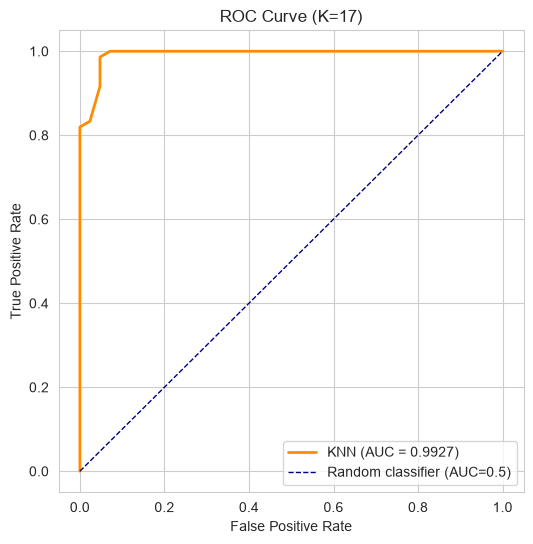

In [18]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_benign)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'KNN (AUC = {auc:.4f})')
plt.plot([0,1], [0,1], color='navy', lw=1, linestyle='--', label='Random classifier (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (K={FINAL_K})')
plt.legend(loc='lower right')
plt.show()

**Observation:** The ROC-AUC of **0.9927** is very close to the ideal value of 1.0, indicating the model is **excellent at distinguishing malignant from benign** tumours across all possible classification thresholds, not just the default 0.5 threshold. This single-number summary is especially useful for comparing models or threshold choices in a medical context, independent of class imbalance.

## Task 6: Comparative Study with Regression (Lab 3 Integration)

| Aspect | Regression Metrics (Lab 3) | Classification Metrics (this lab) |
|---|---|---|
| Type of output | Continuous numeric value | Discrete class label / probability |
| Core question answered | "How far off is the prediction?" | "Was the decision correct?" |
| Key metrics | MAE, MSE, RMSE, R² | Accuracy, Precision, Recall, F1, ROC-AUC |
| Error representation | Magnitude of numeric deviation | Right/wrong decision (confusion matrix) |
| Sensitive to | Outliers, scale of target variable | Class imbalance, decision threshold |

**1. R² Score vs Accuracy** — R² measures the **proportion of variance** in a continuous target explained by the model (0 to 1, can be negative for a poor fit), while Accuracy measures the **proportion of correctly classified samples** out of all predictions. Both are "headline" summary metrics, but R² is about explained variance in numbers, whereas Accuracy is about counting correct/incorrect labels — and, like R², Accuracy can be **misleading on imbalanced data** (here 63% Benign vs 37% Malignant means a model that always predicts "Benign" would still score ~63% accuracy without learning anything).

**2. RMSE vs F1 Score** — RMSE penalizes **large numeric errors** more heavily (because of squaring) in a continuous prediction, giving a sense of the typical magnitude of error in the same units as the target. F1 Score is the **harmonic mean of Precision and Recall**, balancing false positives and false negatives in classification. Both metrics are used when a *single* error/correctness summary is needed, but RMSE operates on numeric distance while F1 operates on a 2x2 confusion-matrix trade-off.

**3. MAE vs Confusion Matrix** — MAE gives a single **average absolute error** across all predictions in regression. A Confusion Matrix instead **breaks down errors by type** (TP, TN, FP, FN) in classification, which is far more informative for understanding *what kind* of mistake the model makes — critical when some errors (false negatives in cancer diagnosis) are much costlier than others, a distinction MAE-style single numbers cannot capture.

**4. Evaluation logic — continuous vs classification tasks** — In **regression**, the goal is to minimize the *distance* between predicted and actual numeric values, so metrics quantify error magnitude on a continuous scale (e.g., predicting house price, temperature). In **classification**, the goal is to maximize *correct decisions*, so metrics quantify the proportion and type of correct/incorrect categorical assignments — there is no "distance" between "Malignant" and "Benign," only "correct" or "incorrect," making the evaluation logic fundamentally discrete/decision-based rather than continuous/error-based.

### Inference

- **Regression metrics (MAE, MSE, RMSE, R²)** measure how far predicted numeric values deviate from actual values — i.e., the *magnitude* of prediction error on a continuous scale.
- **Classification metrics (Accuracy, Precision, Recall, F1, ROC-AUC)** measure whether a discrete decision/label was *correct*, and further break this down by error type (false positive vs false negative) rather than error size.
- **Accuracy alone is insufficient in medical diagnosis** because the dataset is class-imbalanced (63% Benign) and, more importantly, because accuracy treats a missed cancer diagnosis (false negative) the same as a false alarm (false positive) — even though the real-world cost of missing a malignant tumour is far higher.
- **Recall and ROC-AUC are more relevant in healthcare** because Recall (Sensitivity) directly measures the model's ability to catch all actual positive (malignant) cases, minimizing dangerous false negatives, while ROC-AUC summarizes the model's discriminative power across all decision thresholds, letting clinicians choose a threshold that favors high recall when needed (e.g., screening) without being misled by class imbalance.
- **Overall**, regression evaluation is an *error-magnitude* framework suited to continuous prediction tasks, while classification evaluation is a *decision-correctness* framework suited to categorical tasks — both ultimately quantify "how good is the model," but through fundamentally different mathematical lenses (numeric distance vs. categorical agreement).

## Task 7: Analytical Questions

**1. Why is KNN called a lazy learning algorithm?**
KNN does not build an explicit internal model or learn parameters during a "training phase" — it simply **stores the entire training dataset** and defers all computation (distance calculation, voting) to **prediction time**, when a new query point arrives. Because it does little to no work until it is actually asked to predict, it is called a "lazy" learner, as opposed to "eager" learners (like Linear Regression or Decision Trees) that build a model upfront.

**2. Why is feature scaling required in KNN?**
KNN relies entirely on **distance metrics** (Euclidean/Manhattan) to find nearest neighbours. If features have different scales/units, features with larger numeric ranges dominate the distance calculation, distorting the notion of "closeness." Scaling (e.g., StandardScaler) puts all features on a comparable scale so each contributes fairly to the distance, which directly affects classification outcomes.

**3. Explain heuristic K selection using the √n rule.**
A commonly used rule of thumb sets **K ≈ √n**, where n is the number of training samples — here n=455, giving K≈21.3 (rounded to an odd 21). This heuristic balances the bias-variance trade-off reasonably well for typical datasets: too small a K (relative to data size) overfits to noise, while too large a K oversmooths. It provides a quick, principled starting point that is then refined using accuracy plots and cross-validation, rather than being treated as the final answer.

**4. Why is cross-validation more reliable than a single train-test split?**
A single train-test split gives a performance estimate that depends heavily on **which particular samples** ended up in the test set — an "easy" or "hard" random split can over- or under-state performance. **K-Fold Cross-Validation** repeats training/testing across multiple different folds and averages the results, giving a performance estimate with **lower variance** and making better use of all the data for both training and validation, hence a more trustworthy estimate of how the model generalizes.

**5. How does K affect the bias-variance trade-off?**
- **Small K** (e.g., K=1): the model fits very closely to individual training points → **low bias, high variance** (overfitting, jagged decision boundary, sensitive to noise/outliers).
- **Large K**: predictions are averaged/voted over many neighbours → **high bias, low variance** (oversmoothed, underfitting, may ignore local structure).
The decision boundary plots in Task 3.3 visually confirm this: the boundary at K=1 is jagged and tightly fit, while at K=20 it is smooth and generalized.

**6. Why is recall more important than accuracy in cancer prediction?**
In cancer prediction, a **false negative** (telling a patient with cancer that they are healthy) is far more dangerous than a false positive (an unnecessary follow-up test for a healthy patient). Recall specifically measures the proportion of actual malignant cases correctly identified, directly minimizing dangerous false negatives — whereas accuracy can stay high even while missing several malignant cases, especially under class imbalance, making it a poor sole metric for this safety-critical task.

**7. What is the limitation of very large K values?**
Very large K values cause the model to consider too many (possibly irrelevant or distant) neighbours when making a prediction, **oversmoothing the decision boundary** and pulling predictions toward the majority class. This increases bias, reduces sensitivity to local patterns, can degrade performance on minority classes (like Malignant here), and — as K approaches n — effectively makes every prediction the same as the overall majority class, eliminating the model's discriminative power entirely.

## Conclusion

- Using the **√n heuristic**, an initial K of **21** was computed from 455 training samples (80:20 split). Fine-tuning K ± 5 and validating with **5-fold and 10-fold Stratified Cross-Validation** identified **K = 17** as the optimal, most stable choice, agreeing closely with the heuristic estimate.
- **Train-test split variations** (80:20, 70:30, 90:10) showed that accuracy estimates shift somewhat with split ratio (0.9474–0.9825), with smaller test sets giving less reliable (higher-variance) estimates — reinforcing the value of cross-validation over a single split.
- The **final KNN model (K=17)** achieved strong performance on the held-out test set: **Accuracy = 0.9737, Malignant Precision = 1.00, Malignant Recall = 0.9286, Malignant F1 = 0.9630, ROC-AUC = 0.9927**, correctly catching 39 of 42 malignant cases (3 false negatives) with zero false alarms — performance that should be reported via Recall/ROC-AUC rather than Accuracy alone in a cancer-screening application.
- **Regression vs Classification evaluation:** regression metrics (MAE/MSE/RMSE/R² from Lab 3) quantify *how far off* numeric predictions are, while classification metrics (Accuracy/Precision/Recall/F1/ROC-AUC, this lab) quantify *whether decisions were correct* and *what type of error* occurred. This distinction matters most in domains like healthcare, where **the cost of different error types is unequal**, making Recall and ROC-AUC more clinically meaningful than Accuracy or simple error-magnitude metrics.
- **Key insight carried from Lab 3 to Lab 4:** while Lab 3 focused on minimizing continuous prediction error, this lab shows that for decision-driven, safety-critical tasks, the *type* of error (false negative vs false positive) matters more than a single aggregate error or accuracy number.